# Assignment 9.1 - Backpropagation

Please submit your solution of this notebook in the Whiteboard at the corresponding Assignment entry as .ipynb-file and as .pdf. <br><br>
Please do **NOT** rename the file!

#### State both names of your group members here:
[Rashid Harvey and S M Shameem Ahmed Khan]

## Task 9.1.1: Backpropagation

* Implement a two-layer artificial neural network using `numpy` and/or `torch`with two input neurons and `two` output neurons. Choose the number of hidden neurons to your liking. **(RESULT)**
* Implement a train function that runs the backpropagation algorithm. Don't use `PyTorch`'s autograd functionality. **(RESULT)**
* Our goal is to learn the XOR function. What does the network return for random weights of all combinations of (binary) inputs? **(RESULT)**

Further reading: Rojas book (https://www.inf.fu-berlin.de/inst/ag-ki/rojas_home/documents/1996/NeuralNetworks/neuron.pdf), chapter 7.3.3 and learn about the "matrix way" of implementing backprop.

In [7]:
# Imports
import numpy as np
import torch

# Helper functions
def normalize(data, mean=None, variance=None, ret=False):
    """Normalizes the data to allow for faster convergence of the gradient ascent"""
    if mean is None:
        mean = np.mean(data, axis=0)[np.newaxis,:]
    if variance is None:
        std = np.std(data, axis=0)[np.newaxis,:]
    std[np.where(std == 0)] = 1
    data_ = (data - mean) / std
    if ret:
        return data_
    else:
        return data_, mean, std

def onehot(labels, k):
    n = len(labels)
    onehot_labels = np.zeros([n, k])
    onehot_labels[range(n), labels] = 1
    return onehot_labels

In [ ]:
class NN:   # Feel free to adjust the class structure / functions.
    def __init__(self, input_dim=2, hidden_dim=4, output_dim=2, lr=0.1):
        """
        Two-layer network: input -> hidden -> output.
        Weights initialized small, biases zero.
        """
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.lr = lr

        # Xavier-like initialization for weights
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2. / input_dim)
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2. / hidden_dim)
        self.b2 = np.zeros((1, output_dim))

    def feedforward(self, X):
        """Feed-forward given input X"""
        # Hidden layer
        self.z1 = X @ self.W1 + self.b1
        self.a1 = torch.sigmoid(torch.tensor(self.z1)).numpy()  # Using torch sigmoid but no autograd
        # Output layer
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = torch.sigmoid(torch.tensor(self.z2)).numpy()  # Again, torch sigmoid without autograd
        return self.a2

    def backprop(self, X, y):
        """Manual gradient computation using chain rule."""
        m = X.shape[0]

        # Output layer error
        dz2 = self.a2 - y  # derivative of MSE with sigmoid: (a2 - y) * a2 * (1-a2) but simplified because sigmoid derivative is inside
        dW2 = (self.a1.T @ dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        # Hidden layer error
        da1 = dz2 @ self.W2.T
        dz1 = da1 * (self.a1 * (1 - self.a1))
        dW1 = (X.T @ dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        return dW1, db1, dW2, db2

    def optimize(self, dW1, db1, dW2, db2):
        """Update step using gradient descent."""
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

    def train(self, X, y, epochs=10000, print_loss_every=1000):
        """Train the network using backpropagation."""
        loss_history = []
        for epoch in range(epochs):
            # Forward pass
            preds = self.feedforward(X)

            loss = np.mean((preds - y) ** 2)
            loss_history.append(loss)

            # Backward pass
            dW1, db1, dW2, db2 = self.backprop(X, y)

            # Update weights
            self.optimize(dW1, db1, dW2, db2)

            # Print loss occasionally
            if print_loss_every and (epoch+1) % print_loss_every == 0:
                loss = np.mean((preds - y) ** 2)
                print(f"Epoch {epoch+1}, Loss: {loss:.6f}")
        return loss_history

In [14]:
print("\nRandom weights (untrained) outputs:")
nn_random = NN(input_dim=2, hidden_dim=4, output_dim=2, lr=0.1)
for inp in xor_data:
    out = nn_random.feedforward(inp.reshape(1, -1))
    print(f"Input {inp} -> Output: {out}, Predicted class: {np.argmax(out)}")



Random weights (untrained) outputs:
Input [0 0] -> Output: [[0.59697107 0.4895115 ]], Predicted class: 0
Input [0 1] -> Output: [[0.60088531 0.46072173]], Predicted class: 0
Input [1 0] -> Output: [[0.64182802 0.4390998 ]], Predicted class: 0
Input [1 1] -> Output: [[0.66280019 0.41026669]], Predicted class: 0


## Task 9.1.2: Backpropagation

Implement Backpropagation and optimize the weights of your neural network using the XOR dataset: 

| x | y |
| -------- | ------- |
| (0,0) | 0 |
| (0,1) | 1 |
| (1,0) | 1 |
| (1,1) | 0 |

* How many training iterations do you need? Plot the network error over the number of iterations **(RESULT)**

In [15]:
# XOR dataset
xor_data = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1],
])
xor_labels = onehot(np.array([0, 1, 1, 0]), 2)

# Create network
nn = NN(input_dim=2, hidden_dim=4, output_dim=2, lr=0.5)

# Train and collect loss history
loss_history = nn.train(xor_data, xor_labels, epochs=10000, print_loss_every=2500)

# Determine iterations needed for convergence (loss < 0.01)
loss_threshold = 0.01
for i, loss in enumerate(loss_history):
    if loss < loss_threshold:
        iterations_needed = i + 1
        print(f"\nLoss dropped below {loss_threshold} at iteration {iterations_needed}")
        break
else:
    iterations_needed = len(loss_history)
    print(f"\nLoss did not drop below {loss_threshold} in {iterations_needed} iterations")

Epoch 2500, Loss: 0.000023
Epoch 5000, Loss: 0.000004
Epoch 7500, Loss: 0.000002
Epoch 10000, Loss: 0.000001

Loss dropped below 0.01 at iteration 499


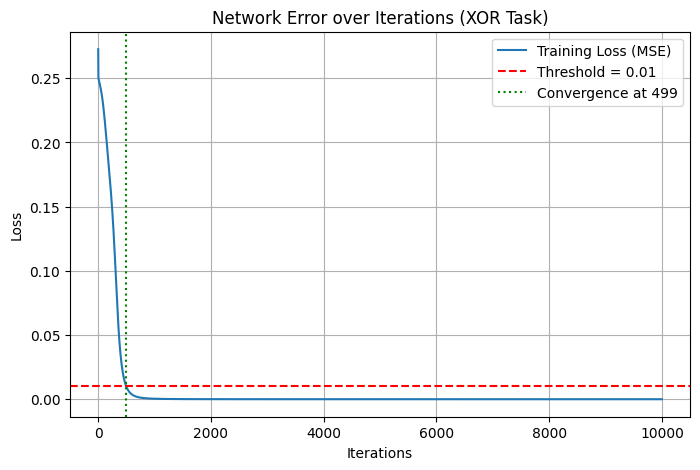

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(loss_history, label='Training Loss (MSE)')
plt.axhline(y=loss_threshold, color='r', linestyle='--', label=f'Threshold = {loss_threshold}')
if iterations_needed < len(loss_history):
    plt.axvline(x=iterations_needed, color='g', linestyle=':', label=f'Convergence at {iterations_needed}')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Network Error over Iterations (XOR Task)')
plt.legend()
plt.grid(True)
plt.show()

## Task 9.1.3: MNIST (BONUS)

* Train your network on the [MNIST dataset](http://yann.lecun.com/exdb/mnist/) and state the model accuracy (or the model error) for the training and test sets. **(RESULT)** 
* Compare to this [list](https://rodrigob.github.io/are_we_there_yet/build/classification_datasets_results.html#4d4e495354) and report on the performance of your model. **(RESULT)**

In [19]:
# You can access MNIST using torchvision (https://pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html)
import torchvision.datasets as datasets

mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=None)
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=None)

mnist_train_data = mnist_train.data.numpy()
mnist_train_labels = mnist_train.targets.numpy()
mnist_test_data = mnist_test.data.numpy()
mnist_test_labels = mnist_test.targets.numpy()

100%|██████████| 9.91M/9.91M [00:01<00:00, 7.07MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 267kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.36MB/s]


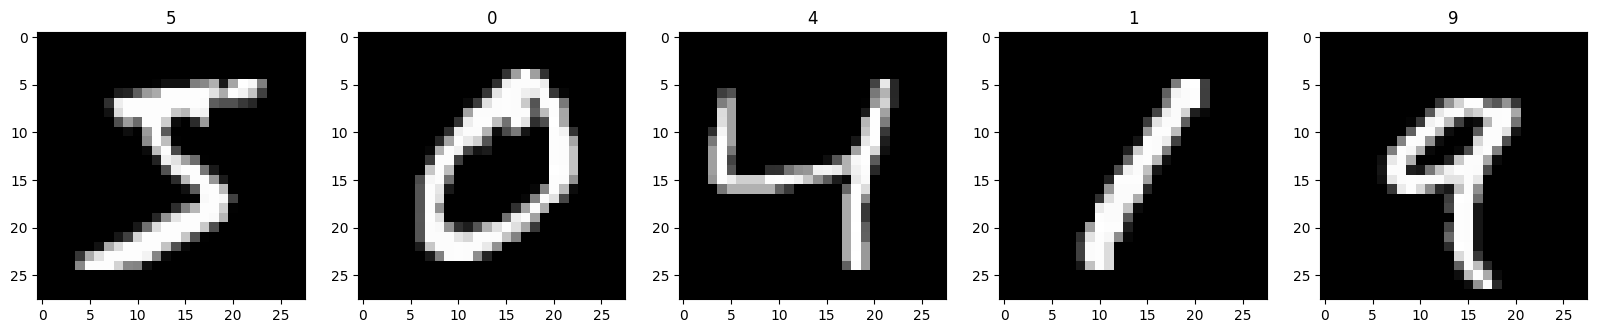

In [20]:
images, labels = mnist_train_data[:5], mnist_train_labels[:5]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i in range(5):
    axes[i].set_title(labels[i])
    axes[i].imshow(images[i], cmap='gray')

In [21]:
mnist_train_data_, mean, mu = normalize(mnist_train_data.reshape([-1, 28*28]))
mnist_train_labels_ = onehot(mnist_train_labels, 10)
print(mnist_train_data_.shape)

In [23]:
class MNIST_NN:
    def __init__(self, input_dim=784, hidden_dim=128, output_dim=10, lr=0.1):
        """
        Two-layer network for MNIST: input (784) -> hidden -> output (10).
        """
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.lr = lr

        # Xavier-like initialization for weights
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2. / input_dim)
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2. / hidden_dim)
        self.b2 = np.zeros((1, output_dim))

    def sigmoid(self, x):
        """Numerically stable sigmoid."""
        return np.where(x >= 0, 
                        1 / (1 + np.exp(-x)), 
                        np.exp(x) / (1 + np.exp(x)))

    def feedforward(self, X):
        """Feed-forward given input X."""
        # Hidden layer
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.sigmoid(self.z1)
        # Output layer
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def backprop(self, X, y):
        """Manual gradient computation using chain rule."""
        m = X.shape[0]

        # Output layer error
        dz2 = self.a2 - y
        dW2 = (self.a1.T @ dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        # Hidden layer error
        da1 = dz2 @ self.W2.T
        dz1 = da1 * (self.a1 * (1 - self.a1))
        dW1 = (X.T @ dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        return dW1, db1, dW2, db2

    def optimize(self, dW1, db1, dW2, db2):
        """Update step using gradient descent."""
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

    def train(self, X, y, epochs=50, batch_size=64, print_loss_every=10):
        """Train the network using mini-batch backpropagation."""
        n_samples = X.shape[0]
        loss_history = []
        
        for epoch in range(epochs):
            # Shuffle data
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            
            epoch_loss = 0
            n_batches = 0
            
            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]
                
                # Forward pass
                preds = self.feedforward(X_batch)
                
                # Compute loss
                batch_loss = np.mean((preds - y_batch) ** 2)
                epoch_loss += batch_loss
                n_batches += 1
                
                # Backward pass
                dW1, db1, dW2, db2 = self.backprop(X_batch, y_batch)
                
                # Update weights
                self.optimize(dW1, db1, dW2, db2)
            
            avg_loss = epoch_loss / n_batches
            loss_history.append(avg_loss)
            
            if print_loss_every and (epoch + 1) % print_loss_every == 0:
                print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")
        
        return loss_history

    def predict(self, X):
        """Return predicted class labels."""
        probs = self.feedforward(X)
        return np.argmax(probs, axis=1)

    def accuracy(self, X, y_true):
        """Compute accuracy given data and true labels (not one-hot)."""
        preds = self.predict(X)
        return np.mean(preds == y_true)


# Prepare test data with same normalization
mnist_test_data_ = normalize(mnist_test_data.reshape([-1, 28*28]), mean=mean, ret=True)

# Create and train MNIST network
mnist_nn = MNIST_NN(input_dim=784, hidden_dim=128, output_dim=10, lr=0.5)
loss_history_mnist = mnist_nn.train(mnist_train_data_, mnist_train_labels_, epochs=50, batch_size=64, print_loss_every=10)

# Evaluate
train_acc = mnist_nn.accuracy(mnist_train_data_, mnist_train_labels)
test_acc = mnist_nn.accuracy(mnist_test_data_, mnist_test_labels)

print(f"\nTraining Accuracy: {train_acc*100:.2f}%")
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Training Error Rate: {(1-train_acc)*100:.2f}%")
print(f"Test Error Rate: {(1-test_acc)*100:.2f}%")

Epoch 10/50, Loss: 0.001574
Epoch 20/50, Loss: 0.000320
Epoch 30/50, Loss: 0.000098
Epoch 40/50, Loss: 0.000041
Epoch 50/50, Loss: 0.000020

Training Accuracy: 100.00%
Test Accuracy: 96.78%
Training Error Rate: 0.00%
Test Error Rate: 3.22%


Ok-ish performance (error-rate 7%+), still a large gap to state-of-the-art models (error-rate 0.21%).

Mini-batch training might be responsible for the better performance

## Congratz, you made it! :)